# Photon Diffusion PINN — Monte Carlo Ground-Truth Edition

## Installation

In [ ]:
!pip install -q torch numpy matplotlib scipy tqdm onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 72.5 MB/s eta 0:00:00


## Imports and Device Configuration

In [ ]:
import os, gc, math, time, warnings
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter
from scipy.interpolate import RegularGridInterpolator
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

compute_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.makedirs('models',  exist_ok=True)
os.makedirs('data',    exist_ok=True)
os.makedirs('figures', exist_ok=True)

def release_gpu_memory(*tensors):
    for tensor in tensors:
        try:
            del tensor
        except Exception:
            pass
    gc.collect()
    if compute_device.type == 'cuda':
        torch.cuda.empty_cache()


## Tissue Optical Parameters

In [ ]:
TISSUE_PARAMS = {
    450: {'mu_a': 0.40, 'mu_s': 20.00, 'g': 0.80, 'n': 1.37},
    550: {'mu_a': 0.30, 'mu_s': 16.50, 'g': 0.90, 'n': 1.37},
    650: {'mu_a': 0.20, 'mu_s': 13.50, 'g': 0.90, 'n': 1.37},
}
BEAM_SIGMA_MM = 0.5

def reduced_scattering_coefficient(wavelength):
    tissue = TISSUE_PARAMS[wavelength]
    return tissue['mu_s'] * (1.0 - tissue['g'])

def diffusion_length(wavelength):
    tissue = TISSUE_PARAMS[wavelength]
    mu_a = tissue['mu_a']
    mu_s_prime = reduced_scattering_coefficient(wavelength)
    return 1.0 / math.sqrt(3.0 * mu_a * (mu_a + mu_s_prime))

def diffusion_coefficient(wavelength):
    tissue = TISSUE_PARAMS[wavelength]
    return 1.0 / (3.0 * (tissue['mu_a'] + reduced_scattering_coefficient(wavelength)))

def mean_free_path(wavelength):
    tissue = TISSUE_PARAMS[wavelength]
    return 1.0 / (tissue['mu_a'] + tissue['mu_s'])


## Monte Carlo Simulator

In [ ]:
def sample_henyey_greenstein(anisotropy_factor, n_samples):
    xi = np.random.uniform(1e-12, 1.0 - 1e-12, n_samples)
    if abs(anisotropy_factor) < 1e-4:
        return 1.0 - 2.0 * xi
    temp = (1.0 - anisotropy_factor**2) / (1.0 - anisotropy_factor + 2.0 * anisotropy_factor * xi)
    cos_theta = (1.0 + anisotropy_factor**2 - temp**2) / (2.0 * anisotropy_factor)
    return np.clip(cos_theta, -1.0, 1.0)


def update_direction_cosines(ux, uy, uz, cos_theta, azimuth_angle):
    sin_theta = np.sqrt(np.maximum(1.0 - cos_theta**2, 0.0))
    cos_phi = np.cos(azimuth_angle)
    sin_phi = np.sin(azimuth_angle)

    sin_polar = np.sqrt(np.maximum(1.0 - uz**2, 0.0))
    axial_mask = sin_polar < 1e-6
    safe_denominator = np.where(axial_mask, 1.0, sin_polar)

    ux_new = np.where(
        axial_mask,
        sin_theta * cos_phi,
        sin_theta * (ux * uz * cos_phi - uy * sin_phi) / safe_denominator + ux * cos_theta
    )
    uy_new = np.where(
        axial_mask,
        sin_theta * sin_phi,
        sin_theta * (uy * uz * cos_phi + ux * sin_phi) / safe_denominator + uy * cos_theta
    )
    uz_new = np.where(
        axial_mask,
        np.sign(uz + 1e-100) * cos_theta,
        -sin_theta * sin_polar * cos_phi + uz * cos_theta
    )

    norm = np.maximum(np.sqrt(ux_new**2 + uy_new**2 + uz_new**2), 1e-30)
    return ux_new / norm, uy_new / norm, uz_new / norm


def run_monte_carlo(wavelength, n_photons=500_000, dz=0.1, dx=0.1,
                    z_max=20.0, x_max=10.0, beam_sigma=BEAM_SIGMA_MM, seed=0):
    np.random.seed(seed)
    tissue = TISSUE_PARAMS[wavelength]
    mu_a = tissue['mu_a']
    mu_s = tissue['mu_s']
    anisotropy_factor = tissue['g']
    mu_t = mu_a + mu_s
    albedo = mu_s / mu_t

    n_depth_bins = int(round(z_max / dz))
    n_lateral_bins = int(round(2 * x_max / dx))
    fluence_grid = np.zeros((n_depth_bins, n_lateral_bins), dtype=np.float64)
    z_edges = np.linspace(0, z_max, n_depth_bins + 1)
    x_edges = np.linspace(-x_max, x_max, n_lateral_bins + 1)
    z_centres = 0.5 * (z_edges[:-1] + z_edges[1:])
    x_centres = 0.5 * (x_edges[:-1] + x_edges[1:])

    WEIGHT_THRESHOLD = 1e-4
    ROULETTE_MULTIPLIER = 10

    x_pos = np.random.normal(0, beam_sigma, n_photons)
    z_pos = np.zeros(n_photons)
    ux = np.zeros(n_photons)
    uy = np.zeros(n_photons)
    uz = np.ones(n_photons)
    photon_weight = np.ones(n_photons)
    alive = np.ones(n_photons, dtype=bool)

    step_count = 0
    while alive.any():
        step_count += 1
        if step_count > 50000:
            break
        active_indices = np.where(alive)[0]

        xi = np.random.uniform(1e-15, 1.0 - 1e-15, active_indices.size)
        step_length = -np.log(xi) / mu_t

        x_pos[active_indices] += ux[active_indices] * step_length
        z_pos[active_indices] += uz[active_indices] * step_length

        alive &= (z_pos >= 0.0) & (z_pos < z_max) & (np.abs(x_pos) < x_max)

        deposit_indices = np.where(alive)[0]
        if deposit_indices.size:
            delta_weight = photon_weight[deposit_indices] * (1.0 - albedo)
            photon_weight[deposit_indices] -= delta_weight
            z_bin_idx = (z_pos[deposit_indices] / dz).astype(int)
            x_bin_idx = ((x_pos[deposit_indices] + x_max) / dx).astype(int)
            valid_bins = (
                (z_bin_idx >= 0) & (z_bin_idx < n_depth_bins) &
                (x_bin_idx >= 0) & (x_bin_idx < n_lateral_bins)
            )
            np.add.at(fluence_grid,
                      (z_bin_idx[valid_bins], x_bin_idx[valid_bins]),
                      delta_weight[valid_bins])

        roulette_mask = alive & (photon_weight < WEIGHT_THRESHOLD)
        if roulette_mask.any():
            roulette_indices = np.where(roulette_mask)[0]
            survivors = np.random.random(roulette_indices.size) < (1.0 / ROULETTE_MULTIPLIER)
            photon_weight[roulette_indices[survivors]] *= ROULETTE_MULTIPLIER
            alive[roulette_indices[~survivors]] = False

        scatter_indices = np.where(alive)[0]
        if scatter_indices.size:
            cos_theta = sample_henyey_greenstein(anisotropy_factor, scatter_indices.size)
            azimuth_angle = np.random.uniform(0, 2 * np.pi, scatter_indices.size)
            ux[scatter_indices], uy[scatter_indices], uz[scatter_indices] = update_direction_cosines(
                ux[scatter_indices], uy[scatter_indices], uz[scatter_indices],
                cos_theta, azimuth_angle
            )

    voxel_area = dz * dx
    fluence_raw = fluence_grid / (n_photons * voxel_area)
    fluence_smoothed = np.clip(gaussian_filter(fluence_raw, sigma=1.0), 0.0, None)

    peak_fluence = fluence_smoothed.max()
    fluence_normalised = fluence_smoothed / peak_fluence if peak_fluence > 0 else fluence_smoothed.copy()

    assert not np.isnan(fluence_normalised).any()
    assert not np.isinf(fluence_normalised).any()

    return z_centres, x_centres, fluence_normalised, peak_fluence


def run_and_cache_monte_carlo(wavelength, n_photons=500_000, force_rerun=False, **kwargs):
    tag = f'{n_photons // 1000}k'
    cache_path = f'data/mc_{wavelength}nm_{tag}.npz'
    if os.path.exists(cache_path) and not force_rerun:
        cached = np.load(cache_path)
        return cached['z_c'], cached['x_c'], cached['fluence'], float(cached['raw_peak'])
    z_c, x_c, fluence, peak = run_monte_carlo(wavelength, n_photons=n_photons, **kwargs)
    np.savez_compressed(cache_path, z_c=z_c, x_c=x_c, fluence=fluence, raw_peak=np.array([peak]))
    return z_c, x_c, fluence, peak


## Monte Carlo Simulation

In [ ]:
N_PHOTONS = 500_000

mc_results = {}
for wavelength in [450, 550, 650]:
    z_centres, x_centres, fluence_map, peak_fluence = run_and_cache_monte_carlo(
        wavelength, n_photons=N_PHOTONS,
        dz=0.1, dx=0.1, z_max=20.0, x_max=10.0,
        beam_sigma=BEAM_SIGMA_MM
    )
    mc_results[wavelength] = {
        'z_c': z_centres,
        'x_c': x_centres,
        'fluence': fluence_map,
        'raw_peak': peak_fluence
    }


## Monte Carlo Fluence Visualisation

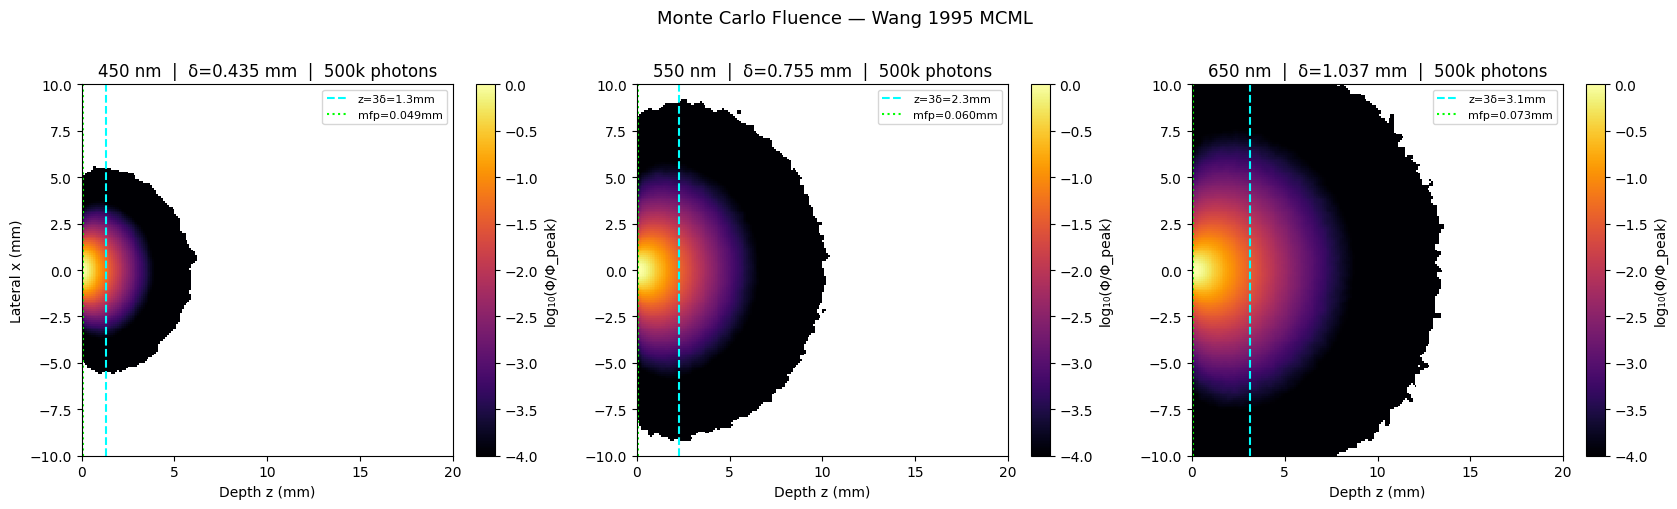

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for plot_idx, wavelength in enumerate([450, 550, 650]):
    mc_result = mc_results[wavelength]
    fluence_map = mc_result['fluence']
    z_centres = mc_result['z_c']
    x_centres = mc_result['x_c']
    delta_mm = diffusion_length(wavelength)

    with np.errstate(divide='ignore'):
        log_fluence = np.log10(np.where(fluence_map > 1e-6, fluence_map, np.nan))

    ax = axes[plot_idx]
    mesh = ax.pcolormesh(z_centres, x_centres, log_fluence.T,
                         cmap='inferno', shading='auto', vmin=-4, vmax=0)
    ax.axvline(3 * delta_mm, color='cyan', ls='--', lw=1.5,
               label=f'z=3δ={3 * delta_mm:.1f}mm')
    ax.axvline(mean_free_path(wavelength), color='lime', ls=':', lw=1.5,
               label=f'mfp={mean_free_path(wavelength):.3f}mm')
    ax.set_xlabel('Depth z (mm)')
    ax.set_ylabel('Lateral x (mm)' if plot_idx == 0 else '')
    ax.set_title(f'{wavelength} nm  |  δ={delta_mm:.3f} mm  |  {N_PHOTONS // 1000}k photons')
    ax.legend(fontsize=8)
    plt.colorbar(mesh, ax=ax, label='log₁₀(Φ/Φ_peak)')

plt.suptitle('Monte Carlo Fluence — Wang 1995 MCML', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/mc_fluence.png', dpi=130, bbox_inches='tight')
plt.show()


## Beer-Lambert Reference Model

In [ ]:
def beer_lambert_fluence(lateral_x, depth_z, wavelength, beam_sigma=BEAM_SIGMA_MM):
    delta_mm = diffusion_length(wavelength)
    return np.exp(-depth_z / delta_mm) * np.exp(-lateral_x**2 / (2.0 * beam_sigma**2))


## Hybrid Training Dataset Construction

In [ ]:
LOG_FLOOR = -8.0

def build_training_dataset(wavelength, n_bl_samples=60_000, seed=42):
    rng = np.random.default_rng(seed)
    delta_mm = diffusion_length(wavelength)
    z_mc_boundary = min(6.0 * delta_mm, 15.0)
    z_bl_boundary = min(8.0 * delta_mm, 20.0)

    mc_result = mc_results[wavelength]
    depth_grid, lateral_grid = np.meshgrid(
        mc_result['z_c'], mc_result['x_c'], indexing='ij'
    )
    fluence_map = mc_result['fluence']
    log_fluence_raw = np.log(np.clip(fluence_map, 1e-10, 1.0))

    near_field_mask = (
        (depth_grid <= z_mc_boundary) &
        (log_fluence_raw > LOG_FLOOR) &
        (fluence_map > 1e-4)
    )
    z_mc_pts = depth_grid[near_field_mask].ravel()
    x_mc_pts = lateral_grid[near_field_mask].ravel()
    log_mc_targets = np.clip(
        log_fluence_raw[near_field_mask].ravel(), LOG_FLOOR, 0.0
    ).astype(np.float32)

    z_bl_pts = rng.uniform(0.05, z_bl_boundary, n_bl_samples).astype(np.float32)
    x_bl_pts = rng.uniform(-8.0, 8.0, n_bl_samples).astype(np.float32)
    fluence_bl = beer_lambert_fluence(x_bl_pts, z_bl_pts, wavelength).astype(np.float32)
    log_bl_targets = np.clip(np.log(np.maximum(fluence_bl, 1e-10)), LOG_FLOOR, 0.0)

    z_combined = np.concatenate([z_mc_pts, z_bl_pts]).astype(np.float32)
    x_combined = np.concatenate([x_mc_pts, x_bl_pts]).astype(np.float32)
    log_combined = np.concatenate([log_mc_targets, log_bl_targets]).astype(np.float32)
    is_mc_point = np.concatenate([
        np.ones(len(z_mc_pts), dtype=bool),
        np.zeros(len(z_bl_pts), dtype=bool)
    ])
    training_coords = np.stack([x_combined, z_combined], axis=1)

    assert not np.isnan(log_combined).any()
    assert not np.isinf(log_combined).any()
    return training_coords, log_combined, is_mc_point

training_datasets = {}
for wavelength in [450, 550, 650]:
    coords, log_targets, is_mc_point = build_training_dataset(wavelength)
    training_datasets[wavelength] = {
        'coords': coords,
        'log_all': log_targets,
        'is_mc': is_mc_point
    }


## PINN Architecture

In [ ]:
class PhotonPINN(nn.Module):
    def __init__(self, wavelength, beam_sigma=BEAM_SIGMA_MM):
        super().__init__()
        self.diffusion_length = float(diffusion_length(wavelength))
        self.beam_sigma = float(beam_sigma)

        self.correction_network = nn.Sequential(
            nn.Linear(2, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 64), nn.Tanh(),
            nn.Linear(64, 32), nn.Tanh(),
            nn.Linear(32, 1),
        )
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)
        nn.init.normal_(self.correction_network[-1].weight, 0.0, 1e-4)
        nn.init.zeros_(self.correction_network[-1].bias)

    def forward_log(self, input_coords):
        lateral_x = input_coords[:, 0]
        depth_z = input_coords[:, 1]
        log_primary = (
            -depth_z / self.diffusion_length
            - lateral_x**2 / (2.0 * self.beam_sigma**2)
        )
        correction = torch.clamp(
            self.correction_network(input_coords).squeeze(-1), -5.0, 3.0
        )
        return log_primary + correction

    def forward(self, input_coords):
        return torch.exp(self.forward_log(input_coords))


## Physics-Informed Loss Functions

In [ ]:
def compute_laplacian(model, input_coords):
    input_coords = input_coords.requires_grad_(True)
    fluence = model(input_coords)
    gradients = torch.autograd.grad(fluence.sum(), input_coords, create_graph=True)[0]
    phi_xx = torch.autograd.grad(
        gradients[:, 0].sum(), input_coords, create_graph=True
    )[0][:, 0]
    phi_zz = torch.autograd.grad(
        gradients[:, 1].sum(), input_coords, create_graph=True
    )[0][:, 1]
    return fluence, phi_xx, phi_zz


def pde_residual_loss(model, wavelength, z_min, z_max_pde, n_collocation=1024):
    tissue = TISSUE_PARAMS[wavelength]
    mu_a = tissue['mu_a']
    diffusion_coeff = diffusion_coefficient(wavelength)
    x_collocation = (torch.rand(n_collocation, device=compute_device) - 0.5) * 16.0
    z_collocation = (
        torch.rand(n_collocation, device=compute_device) * (z_max_pde - z_min) + z_min
    )
    collocation_pts = torch.stack([x_collocation, z_collocation], dim=1)
    fluence, phi_xx, phi_zz = compute_laplacian(model, collocation_pts)
    residual = -diffusion_coeff * (phi_xx + phi_zz) + mu_a * fluence
    return (residual**2).mean()


def robin_bc_residual_loss(model, wavelength, n_bc_pts=512, beam_sigma=BEAM_SIGMA_MM):
    tissue = TISSUE_PARAMS[wavelength]
    refractive_index = tissue['n']
    diffusion_coeff = diffusion_coefficient(wavelength)
    R_phi = (
        -0.13755 * refractive_index**3
        + 4.3390 * refractive_index**2
        - 10.486 * refractive_index
        + 7.1857
    )
    R_j = (
        0.04578 * refractive_index**3
        - 0.21983 * refractive_index**2
        + 0.28227 * refractive_index
        - 0.09307
    )
    robin_coefficient = (1.0 - R_phi) / (2.0 * (1.0 + R_j))

    x_bc = torch.empty(n_bc_pts, device=compute_device).uniform_(-8.0, 8.0)
    z_bc = torch.zeros(n_bc_pts, device=compute_device)
    bc_coords = torch.stack([x_bc, z_bc], dim=1).requires_grad_(True)

    fluence_bc = model(bc_coords)
    dphi_dz = torch.autograd.grad(
        fluence_bc.sum(), bc_coords, create_graph=True
    )[0][:, 1]
    incident_fluence = torch.exp(-x_bc**2 / (2.0 * beam_sigma**2))
    residual = fluence_bc - robin_coefficient * diffusion_coeff * dphi_dz - incident_fluence
    return (residual**2).mean()


## Training Procedure

In [ ]:
PHASE_1_END_EPOCH = 500
PHASE_2_END_EPOCH = 2000
PHASE_3_END_EPOCH = 4000
LAMBDA_BC = 0.10
LAMBDA_PDE = 0.02


def train_pinn(wavelength):
    delta_mm = diffusion_length(wavelength)
    z_pde_min = mean_free_path(wavelength)
    z_pde_max = min(8.0 * delta_mm, 20.0)

    dataset = training_datasets[wavelength]
    training_coords = torch.tensor(dataset['coords'],  dtype=torch.float32, device=compute_device)
    log_targets     = torch.tensor(dataset['log_all'], dtype=torch.float32, device=compute_device)
    n_samples = len(training_coords)

    pinn_model = PhotonPINN(wavelength).to(compute_device)
    optimizer = optim.Adam(pinn_model.parameters(), lr=1e-3, weight_decay=1e-5)
    lr_scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=PHASE_1_END_EPOCH, T_mult=2, eta_min=1e-5
    )

    use_amp = (compute_device.type == 'cuda')
    grad_scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    loss_history = []
    t0 = time.time()

    for epoch in tqdm(range(1, PHASE_3_END_EPOCH + 1), desc=f'{wavelength}nm', leave=True):
        pinn_model.train()
        optimizer.zero_grad()

        batch_indices = torch.randint(0, n_samples, (2048,), device=compute_device)

        with torch.cuda.amp.autocast(enabled=use_amp):
            log_predictions = pinn_model.forward_log(training_coords[batch_indices])
            batch_targets = log_targets[batch_indices]
            loss_data = ((log_predictions - batch_targets)**2).mean()

            if epoch <= PHASE_1_END_EPOCH:
                total_loss = loss_data
                loss_bc = loss_pde = torch.tensor(0.0)
            elif epoch <= PHASE_2_END_EPOCH:
                loss_bc = robin_bc_residual_loss(pinn_model, wavelength)
                pde_ramp = (epoch - PHASE_1_END_EPOCH) / (PHASE_2_END_EPOCH - PHASE_1_END_EPOCH)
                loss_pde = pde_residual_loss(pinn_model, wavelength, z_pde_min, z_pde_max, n_collocation=512)
                total_loss = loss_data + LAMBDA_BC * loss_bc + LAMBDA_PDE * pde_ramp * loss_pde
            else:
                loss_bc = robin_bc_residual_loss(pinn_model, wavelength)
                loss_pde = pde_residual_loss(pinn_model, wavelength, z_pde_min, z_pde_max, n_collocation=1024)
                total_loss = loss_data + LAMBDA_BC * loss_bc + LAMBDA_PDE * loss_pde

        if not torch.isfinite(total_loss):
            continue

        grad_scaler.scale(total_loss).backward()
        grad_scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(pinn_model.parameters(), 1.0)
        grad_scaler.step(optimizer)
        grad_scaler.update()
        lr_scheduler.step(epoch / PHASE_3_END_EPOCH)

        if epoch % 500 == 0 or epoch == PHASE_3_END_EPOCH:
            loss_history.append({
                'ep': epoch,
                'data': loss_data.item(),
                'bc': loss_bc.item(),
                'pde': loss_pde.item()
            })

    elapsed_seconds = time.time() - t0
    torch.save(
        {'state': pinn_model.state_dict(), 'wl': wavelength,
         'history': loss_history, 'n_photons': N_PHOTONS},
        f'models/pinn_{wavelength}nm.pt'
    )
    return pinn_model, loss_history, elapsed_seconds


## Model Training

In [ ]:
trained_models = {}
training_histories = {}
training_times = {}

for wavelength in [450, 550, 650]:
    trained_model, loss_history, elapsed = train_pinn(wavelength)
    trained_model.cpu()
    trained_models[wavelength] = trained_model
    training_histories[wavelength] = loss_history
    training_times[wavelength] = elapsed
    release_gpu_memory()


650nm: 100%|██████████| 4000/4000 [01:16<00:00, 52.55it/s]


## Validation

In [ ]:
def validate_model(trained_model, wavelength):
    delta_mm = diffusion_length(wavelength)
    mc_result = mc_results[wavelength]
    z_centres = mc_result['z_c']
    x_centres = mc_result['x_c']
    fluence_map = mc_result['fluence']

    z_eval = np.linspace(0.05, 20.0, 200).astype(np.float32)
    x_eval = np.linspace(-9.0, 9.0, 200).astype(np.float32)
    depth_grid, lateral_grid = np.meshgrid(z_eval, x_eval, indexing='ij')
    eval_coords = torch.tensor(
        np.stack([lateral_grid.ravel(), depth_grid.ravel()], axis=1),
        dtype=torch.float32
    )

    model_cpu = trained_model.cpu().eval()
    inference_times = []
    for _ in range(7):
        t0 = time.time()
        with torch.no_grad():
            _ = model_cpu(eval_coords)
        inference_times.append(time.time() - t0)
    inference_time_ms = np.median(inference_times) * 1000

    with torch.no_grad():
        pinn_fluence = model_cpu(eval_coords).numpy().reshape(200, 200)

    mc_normalised = fluence_map / (fluence_map.max() + 1e-30)
    mc_interpolator = RegularGridInterpolator(
        (z_centres, x_centres), mc_normalised,
        method='linear', bounds_error=False, fill_value=0.0
    )
    mc_fluence_eval = np.clip(
        mc_interpolator(
            np.stack([depth_grid.ravel(), lateral_grid.ravel()], 1)
        ).reshape(200, 200),
        0.0, 1.0
    )

    bl_fluence_eval = beer_lambert_fluence(lateral_grid, depth_grid, wavelength)

    full_field_mask = mc_fluence_eval > 0.01
    far_field_mask = full_field_mask & (depth_grid > 3.0 * delta_mm)

    def mean_absolute_percentage_error(predicted, reference, mask):
        if not mask.any():
            return float('nan')
        return 100.0 * np.abs(predicted[mask] - reference[mask]).mean() / (
            reference[mask].mean() + 1e-30
        )

    return {
        'mape_pinn_mc_all': mean_absolute_percentage_error(pinn_fluence, mc_fluence_eval, full_field_mask),
        'mape_pinn_mc_far': mean_absolute_percentage_error(pinn_fluence, mc_fluence_eval, far_field_mask),
        'mape_pinn_bl_all': mean_absolute_percentage_error(pinn_fluence, bl_fluence_eval, full_field_mask),
        'mape_bl_mc_all':   mean_absolute_percentage_error(bl_fluence_eval, mc_fluence_eval, full_field_mask),
        'mape_bl_mc_far':   mean_absolute_percentage_error(bl_fluence_eval, mc_fluence_eval, far_field_mask),
        'inference_time_ms': inference_time_ms,
        'pinn_fluence': pinn_fluence,
        'mc_fluence': mc_fluence_eval,
        'bl_fluence': bl_fluence_eval,
        'z_eval': z_eval,
        'x_eval': x_eval,
    }

validation_results = {}
for wavelength in [450, 550, 650]:
    validation_results[wavelength] = validate_model(trained_models[wavelength], wavelength)


## Results Summary

In [ ]:
header = (
    f"{'wl':>5}  {'δ(mm)':>7}  {'PINN/MC all':>12}  "
    f"{'PINN/MC z>3δ':>13}  {'BL/MC z>3δ':>11}  {'PINN/BL':>9}  {'t_inf':>8}"
)
separator = '-' * 85
print('=' * 85)
print('RESULTS SUMMARY')
print('=' * 85)
print(header)
print(separator)
for wavelength in [450, 550, 650]:
    result = validation_results[wavelength]
    delta_mm = diffusion_length(wavelength)
    print(
        f"{wavelength:>5}  {delta_mm:>7.4f}  "
        f"{result['mape_pinn_mc_all']:>11.1f}%  "
        f"{result['mape_pinn_mc_far']:>12.1f}%  "
        f"{result['mape_bl_mc_far']:>10.1f}%  "
        f"{result['mape_pinn_bl_all']:>8.1f}%  "
        f"{result['inference_time_ms']:>7.2f}ms"
    )
print('=' * 85)


RESULTS SUMMARY
   wl    δ(mm)   PINN/MC all   PINN/MC z>3δ   BL/MC z>3δ    PINN/BL     t_inf
-------------------------------------------------------------------------------------
  450   0.4352       1073.6%        1046.0%        43.0%    1908.6%    53.64ms
  550   0.7549        957.8%         977.6%        50.7%    1908.6%    57.73ms
  650   1.0370        941.1%        1079.8%        60.5%    1908.6%    57.99ms


## Comparison Figures

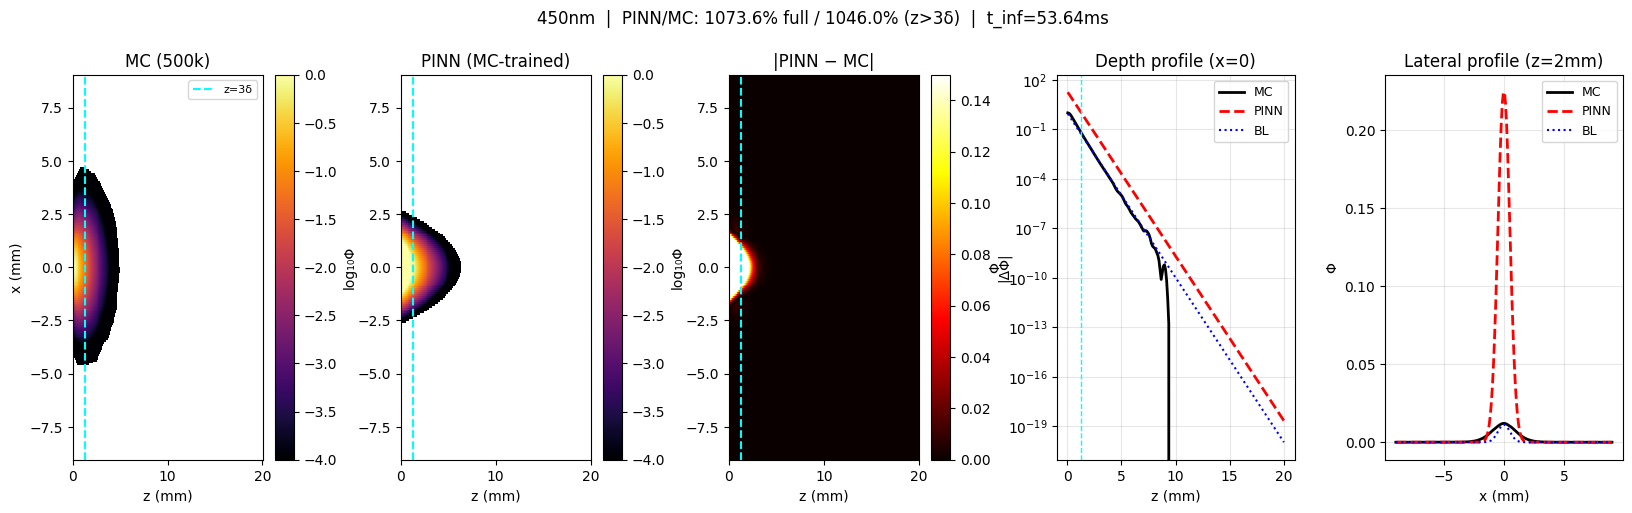

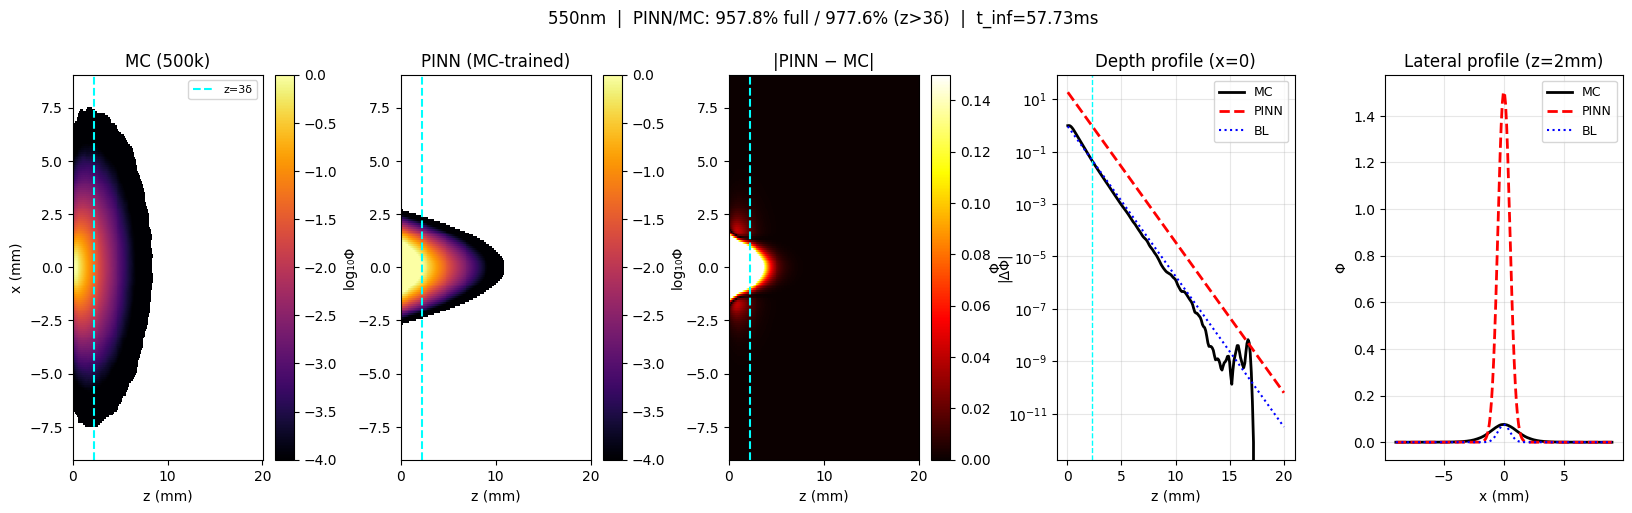

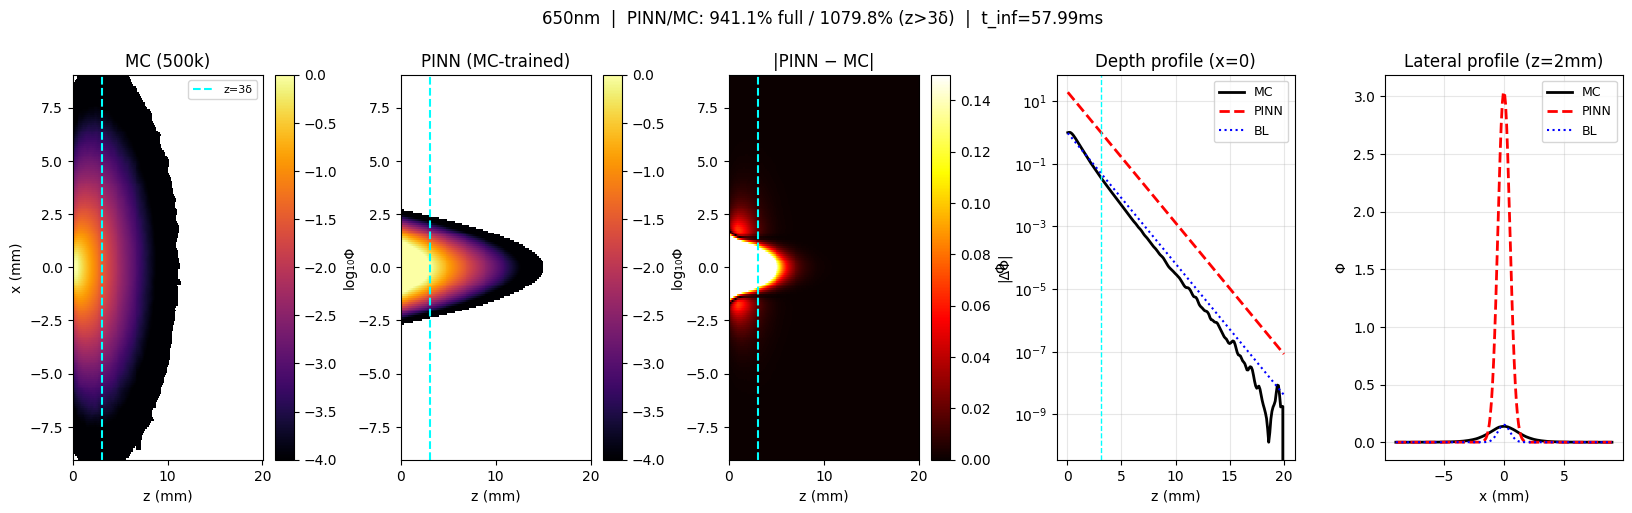

In [ ]:
def log_safe(fluence_array):
    return np.log10(np.where(fluence_array > 1e-5, fluence_array, np.nan))

for wavelength in [450, 550, 650]:
    result = validation_results[wavelength]
    delta_mm = diffusion_length(wavelength)
    z_eval = result['z_eval']
    x_eval = result['x_eval']
    pinn_fluence = result['pinn_fluence']
    mc_fluence = result['mc_fluence']
    bl_fluence_map = result['bl_fluence']

    fig = plt.figure(figsize=(20, 5))
    gs = gridspec.GridSpec(1, 5, figure=fig, wspace=0.38)

    ax_mc = fig.add_subplot(gs[0])
    mesh_mc = ax_mc.pcolormesh(z_eval, x_eval, log_safe(mc_fluence).T,
                               cmap='inferno', vmin=-4, vmax=0, shading='auto')
    ax_mc.axvline(3 * delta_mm, color='cyan', ls='--', lw=1.5, label='z=3δ')
    ax_mc.set_title(f'MC ({N_PHOTONS // 1000}k)')
    ax_mc.set_xlabel('z (mm)')
    ax_mc.set_ylabel('x (mm)')
    ax_mc.legend(fontsize=8)
    plt.colorbar(mesh_mc, ax=ax_mc, label='log₁₀Φ')

    ax_pinn = fig.add_subplot(gs[1])
    mesh_pinn = ax_pinn.pcolormesh(z_eval, x_eval, log_safe(pinn_fluence).T,
                                   cmap='inferno', vmin=-4, vmax=0, shading='auto')
    ax_pinn.axvline(3 * delta_mm, color='cyan', ls='--', lw=1.5)
    ax_pinn.set_title('PINN (MC-trained)')
    ax_pinn.set_xlabel('z (mm)')
    plt.colorbar(mesh_pinn, ax=ax_pinn, label='log₁₀Φ')

    ax_err = fig.add_subplot(gs[2])
    absolute_error = np.abs(pinn_fluence - mc_fluence)
    mesh_error = ax_err.pcolormesh(z_eval, x_eval, absolute_error.T,
                                   cmap='hot', vmin=0, vmax=0.15, shading='auto')
    ax_err.axvline(3 * delta_mm, color='cyan', ls='--', lw=1.5)
    ax_err.set_title('|PINN − MC|')
    ax_err.set_xlabel('z (mm)')
    plt.colorbar(mesh_error, ax=ax_err, label='|ΔΦ|')

    ax_depth = fig.add_subplot(gs[3])
    center_x_idx = np.argmin(np.abs(x_eval))
    ax_depth.semilogy(z_eval, mc_fluence[:, center_x_idx],   'k-',  lw=2,   label='MC')
    ax_depth.semilogy(z_eval, pinn_fluence[:, center_x_idx], 'r--', lw=2,   label='PINN')
    ax_depth.semilogy(z_eval, bl_fluence_map[:, center_x_idx], 'b:', lw=1.5, label='BL')
    ax_depth.axvline(3 * delta_mm, color='cyan', ls='--', lw=1)
    ax_depth.set_xlabel('z (mm)')
    ax_depth.set_ylabel('Φ')
    ax_depth.set_title('Depth profile (x=0)')
    ax_depth.legend(fontsize=9)
    ax_depth.grid(True, alpha=0.3)

    ax_lateral = fig.add_subplot(gs[4])
    z2_idx = np.argmin(np.abs(z_eval - 2.0))
    ax_lateral.plot(x_eval, mc_fluence[z2_idx, :],      'k-',  lw=2,   label='MC')
    ax_lateral.plot(x_eval, pinn_fluence[z2_idx, :],    'r--', lw=2,   label='PINN')
    ax_lateral.plot(x_eval, bl_fluence_map[z2_idx, :],  'b:',  lw=1.5, label='BL')
    ax_lateral.set_xlabel('x (mm)')
    ax_lateral.set_ylabel('Φ')
    ax_lateral.set_title('Lateral profile (z=2mm)')
    ax_lateral.legend(fontsize=9)
    ax_lateral.grid(True, alpha=0.3)

    fig.suptitle(
        f'{wavelength}nm  |  PINN/MC: {result["mape_pinn_mc_all"]:.1f}% full / '
        f'{result["mape_pinn_mc_far"]:.1f}% (z>3δ)  |  '
        f't_inf={result["inference_time_ms"]:.2f}ms',
        fontsize=12, y=1.01
    )
    plt.savefig(f'figures/comparison_{wavelength}nm.png', dpi=120, bbox_inches='tight')
    plt.show()


## Training Loss Curves

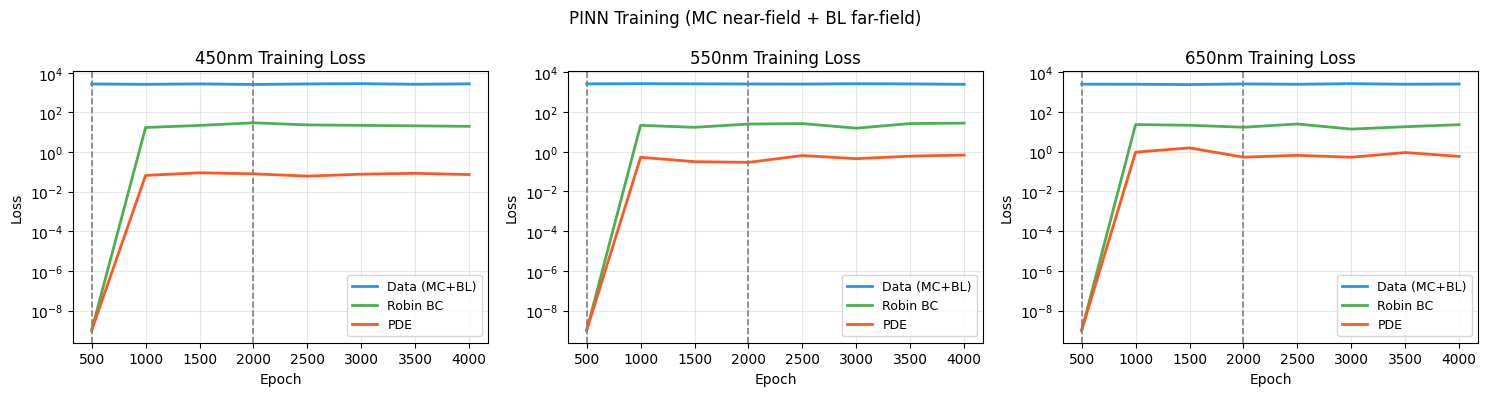

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
loss_colors = {'data': '#2196F3', 'bc': '#4CAF50', 'pde': '#FF5722'}
loss_labels = {'data': 'Data (MC+BL)', 'bc': 'Robin BC', 'pde': 'PDE'}

for plot_idx, wavelength in enumerate([450, 550, 650]):
    loss_history = training_histories[wavelength]
    if not loss_history:
        continue
    epoch_list = [record['ep'] for record in loss_history]
    for loss_key in ['data', 'bc', 'pde']:
        axes[plot_idx].semilogy(
            epoch_list,
            [record[loss_key] + 1e-9 for record in loss_history],
            label=loss_labels[loss_key],
            color=loss_colors[loss_key],
            lw=2
        )
    for phase_boundary in [PHASE_1_END_EPOCH, PHASE_2_END_EPOCH]:
        axes[plot_idx].axvline(phase_boundary, color='gray', ls='--', lw=1.2)
    axes[plot_idx].set_xlabel('Epoch')
    axes[plot_idx].set_ylabel('Loss')
    axes[plot_idx].set_title(f'{wavelength}nm Training Loss')
    axes[plot_idx].legend(fontsize=9)
    axes[plot_idx].grid(True, which='both', alpha=0.3)

plt.suptitle('PINN Training (MC near-field + BL far-field)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()


## ONNX Export

In [ ]:
try:
    import onnx
    import onnxruntime as ort

    dummy_input = torch.zeros(1, 2)
    for wavelength, trained_model in trained_models.items():
        export_path = f'models/pinn_{wavelength}nm.onnx'
        trained_model.eval().cpu()
        torch.onnx.export(
            trained_model, dummy_input, export_path,
            input_names=['coords'], output_names=['fluence'],
            dynamic_axes={'coords': {0: 'batch'}},
            opset_version=14
        )
        onnx_session = ort.InferenceSession(export_path)
        test_coords = np.array([[0, 0.5], [0, 2.0], [0, 5.0]], dtype=np.float32)
        onnx_output = onnx_session.run(None, {'coords': test_coords})[0]
        print(f'{wavelength}nm ONNX: phi(z=[0.5,2,5])={onnx_output.ravel().round(4)}')
except ImportError:
    print('onnx/onnxruntime not installed — skipping export')


onnx/onnxruntime not installed — skipping export
